In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
body_acc_x = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\train\Inertial Signals\body_acc_x_train.txt",
    sep=r"\s+",
    header=None
)

body_acc_y = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\train\Inertial Signals\body_acc_y_train.txt",
    sep=r"\s+",
    header=None
)

body_acc_z = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\train\Inertial Signals\body_acc_z_train.txt",
    sep=r"\s+",
    header=None
)

In [3]:
print(body_acc_x.shape)
print(body_acc_y.shape)
print(body_acc_z.shape)

(7352, 128)
(7352, 128)
(7352, 128)


In [4]:
body_gyro_x = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\train\Inertial Signals\body_gyro_x_train.txt",
    sep=r"\s+",
    header=None
)

body_gyro_y = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\train\Inertial Signals\body_gyro_y_train.txt",
    sep=r"\s+",
    header=None
)

body_gyro_z = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\train\Inertial Signals\body_gyro_z_train.txt",
    sep=r"\s+",
    header=None
)

In [5]:
print(body_gyro_x.shape)
print(body_gyro_y.shape)
print(body_gyro_z.shape)

(7352, 128)
(7352, 128)
(7352, 128)


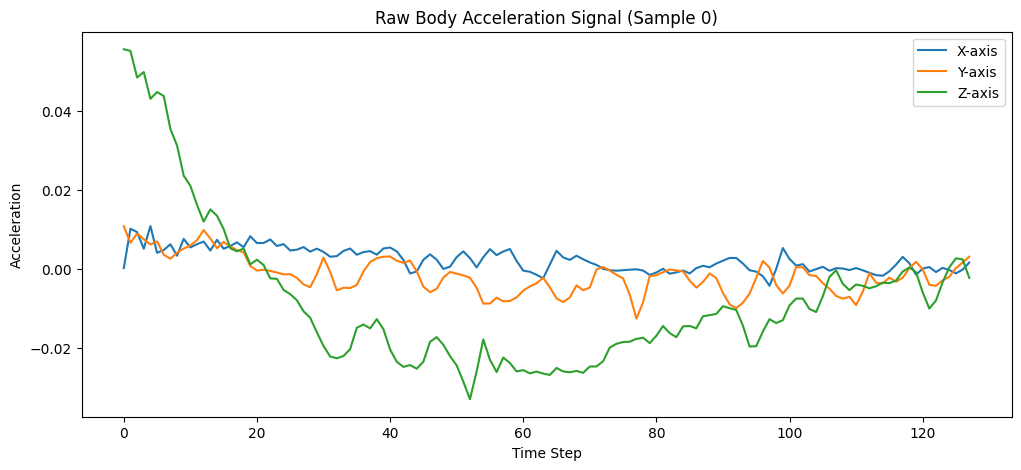

In [7]:
plt.figure(figsize=(12,5))

plt.plot(body_acc_x.iloc[0], label="X-axis")
plt.plot(body_acc_y.iloc[0], label="Y-axis")
plt.plot(body_acc_z.iloc[0], label="Z-axis")

plt.title("Raw Body Acceleration Signal (Sample 0)")
plt.xlabel("Time Step")
plt.ylabel("Acceleration")

plt.legend()
plt.show()

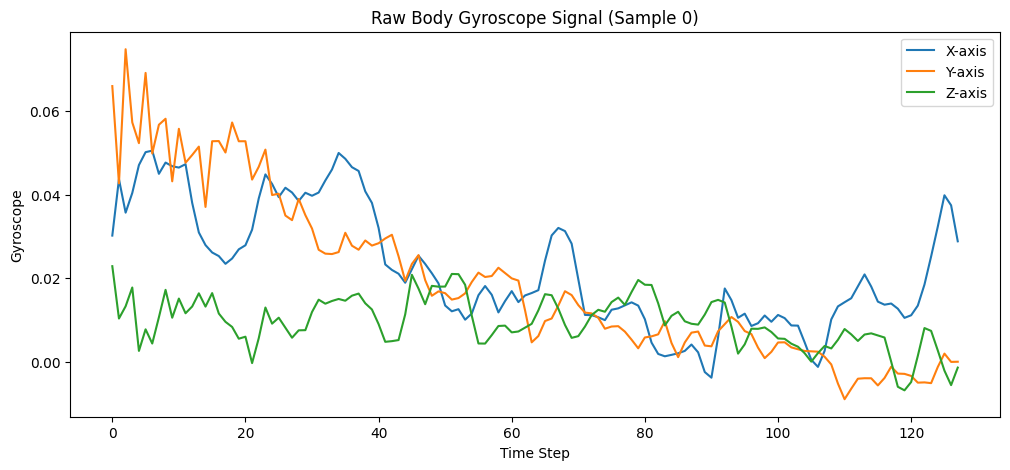

In [8]:
plt.figure(figsize=(12,5))

plt.plot(body_gyro_x.iloc[0], label="X-axis")
plt.plot(body_gyro_y.iloc[0], label="Y-axis")
plt.plot(body_gyro_z.iloc[0], label="Z-axis")

plt.title("Raw Body Gyroscope Signal (Sample 0)")
plt.xlabel("Time Step")
plt.ylabel("Gyroscope")

plt.legend()
plt.show()

In [9]:
X_lstm = np.stack(
    [
        body_acc_x,
        body_acc_y,
        body_acc_z,
        body_gyro_x,
        body_gyro_y,
        body_gyro_z
    ],
    axis=2
)

In [11]:
print(X_lstm.shape)

(7352, 128, 6)


In [12]:
y_train_raw = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\train\y_train.txt",
    header=None
)

In [13]:
y_lstm = y_train_raw[0] - 1

In [14]:
print(y_lstm.unique())

[4 3 5 0 2 1]


In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train_lstm, X_val_lstm, y_train_lstm, y_val_lstm = train_test_split(
    X_lstm,
    y_lstm,
    test_size=0.20,
    random_state=42,
    stratify=y_lstm
)

In [17]:
print(X_train_lstm.shape)
print(X_val_lstm.shape)

(5881, 128, 6)
(1471, 128, 6)


In [21]:
import tensorflow as tf

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [23]:
lstm_model = Sequential([
    
    LSTM(
        64,
        input_shape=(128, 6)
    ),

    Dropout(0.3),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        6,
        activation="softmax"
    )
])

d:\imu-har-exoskeleton-ai\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [25]:
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,454 (79.90 KB)

 Trainable params: 20,454 (79.90 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_data=(
        X_val_lstm,
        y_val_lstm
    ),
    epochs=10,
    batch_size=32
)

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.3423 - loss: 1.4176 - val_accuracy: 0.4086 - val_loss: 1.1389
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4081 - loss: 1.0947 - val_accuracy: 0.4922 - val_loss: 0.9999
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4627 - loss: 1.0276 - val_accuracy: 0.4684 - val_loss: 1.0192
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4596 - loss: 1.0832 - val_accuracy: 0.3243 - val_loss: 1.8587
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.4827 - loss: 0.9711 - val_accuracy: 0.5418 - val_loss: 0.8547
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.5254 - loss: 0.8706 - val_accuracy: 0.5466 - val_loss: 0.8273
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.5567 - loss: 0.8147 - val_accuracy: 0.5758 - val_loss: 0.7609
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.5815 - loss: 0.7728 - val_accu